
Predicted percentages (first 20 patients):
 Patient  Diagnosis(1-Anxiety, 0-No Anxiety)  Logistic Regression (%)  Random Forest (%)  XGBoost (%)
 1       1                                   79.31                     78.96             73.27       
 2       0                                    0.30                      1.16              0.62       
 3       0                                    0.30                      4.07              0.57       
 4       0                                    5.63                     13.09              9.71       
 5       0                                    0.00                      0.18              0.00       
 6       0                                   58.51                     65.57             63.97       
 7       0                                   21.99                     28.99             28.32       
 8       0                                   17.32                     18.73             15.44       
 9       0                            

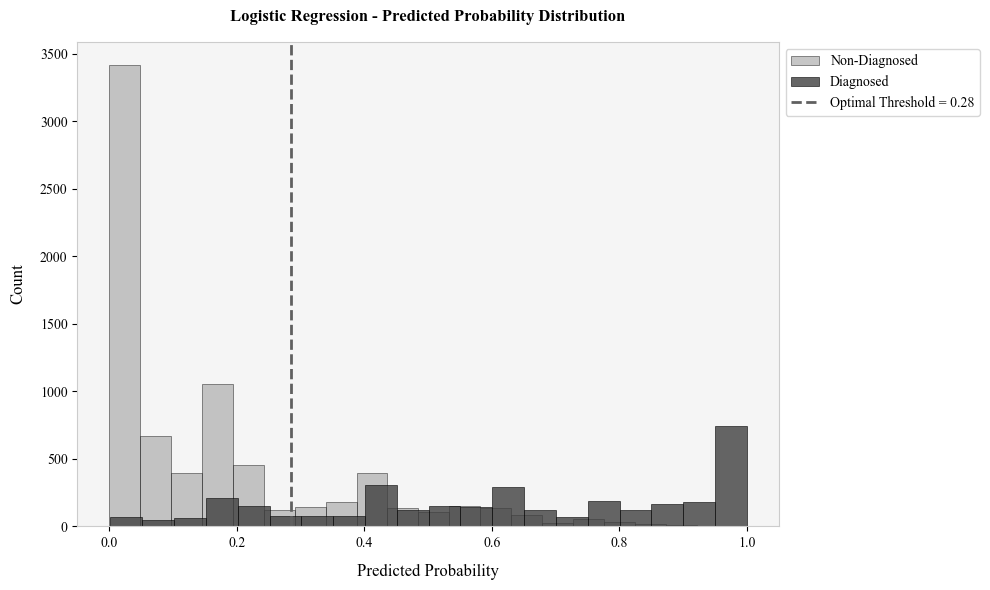

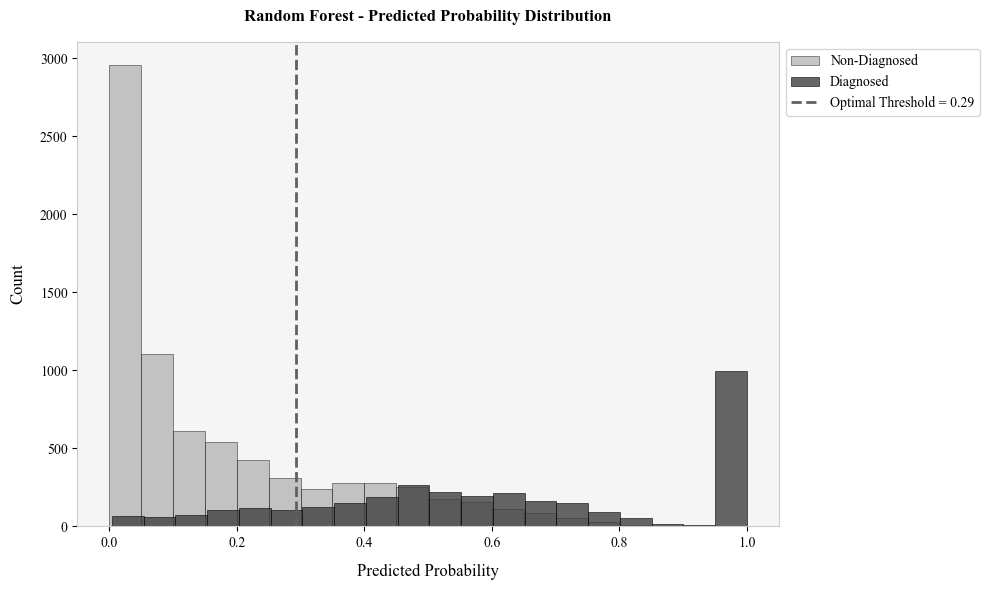

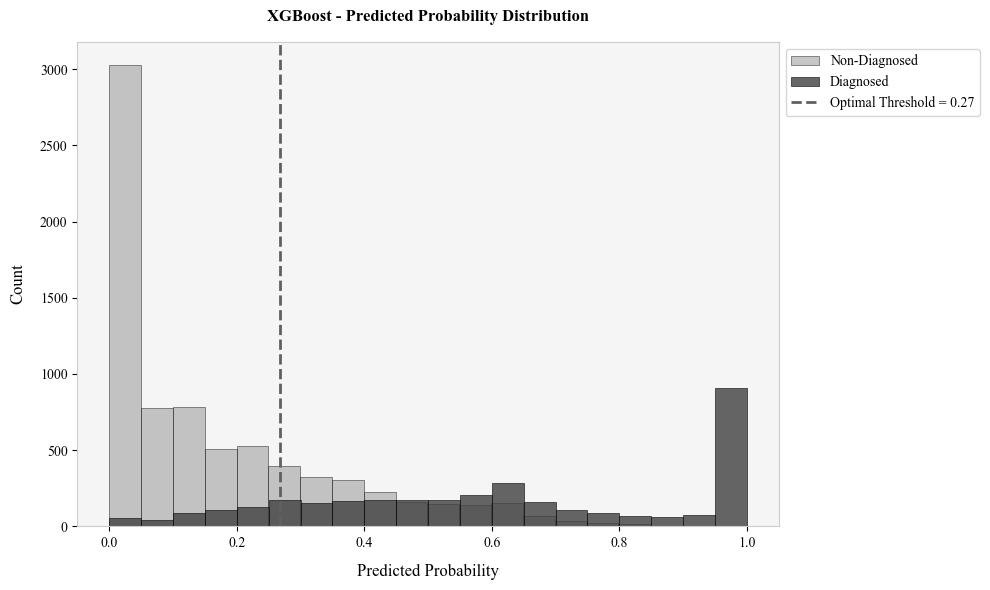


Top 15 features for Logistic Regression:
  Stress Level (1-10): 1.8771 (increases risk)
  Sleep Hours: -0.7585 (decreases risk)
  Therapy Sessions (per month): 0.5317 (increases risk)
  Caffeine Intake (mg/day): 0.4717 (increases risk)
  Occupation_Student: -0.1800 (decreases risk)
  Occupation_Nurse: 0.1441 (increases risk)
  Occupation_Doctor: 0.1422 (increases risk)
  Occupation_Other: 0.1068 (increases risk)
  Medication: 0.0897 (increases risk)
  Recent Major Life Event: 0.0809 (increases risk)
  Occupation_Lawyer: 0.0808 (increases risk)
  Occupation_Athlete: -0.0805 (decreases risk)
  Alcohol Consumption (drinks/week): 0.0738 (increases risk)
  Gender_Other: 0.0732 (increases risk)
  Age: -0.0731 (decreases risk)


/tmp/ipykernel_86214/2612861299.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=True, loc='upper left', bbox_to_anchor=(1, 1))


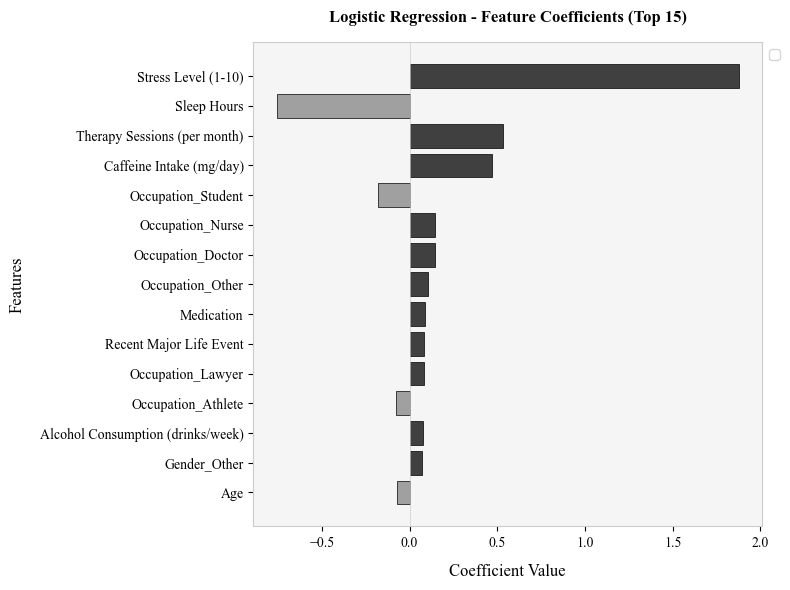


Top 15 features for Random Forest:
  Stress Level (1-10): 0.3114
  Sleep Hours: 0.1086
  Caffeine Intake (mg/day): 0.0850
  Physical Activity (hrs/week): 0.0589
  Therapy Sessions (per month): 0.0552
  Heart Rate (bpm): 0.0536
  Age: 0.0509
  Breathing Rate (breaths/min): 0.0438
  Alcohol Consumption (drinks/week): 0.0428
  Diet Quality (1-10): 0.0404
  Sweating Level (1-5): 0.0271
  Recent Major Life Event: 0.0100
  Medication: 0.0096
  Dizziness: 0.0095
  Gender_Other: 0.0089


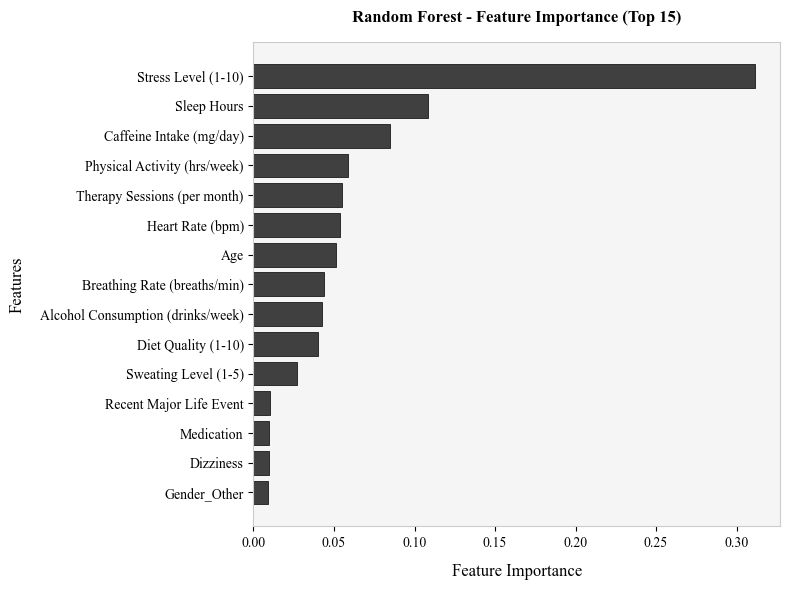


Top 15 features for XGBoost:
  Stress Level (1-10): 0.4402
  Sleep Hours: 0.0664
  Therapy Sessions (per month): 0.0482
  Caffeine Intake (mg/day): 0.0319
  Gender_Male: 0.0246
  Occupation_Athlete: 0.0218
  Occupation_Chef: 0.0201
  Occupation_Scientist: 0.0191
  Sweating Level (1-5): 0.0180
  Alcohol Consumption (drinks/week): 0.0176
  Occupation_Musician: 0.0176
  Diet Quality (1-10): 0.0166
  Occupation_Lawyer: 0.0164
  Age: 0.0162
  Physical Activity (hrs/week): 0.0162


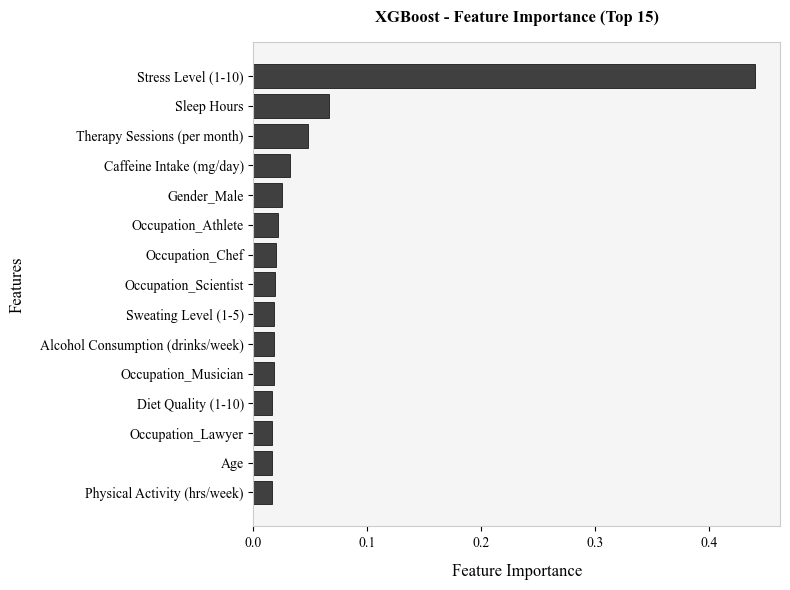

Logistic Regression METRICS (threshold=0.284)
Confusion Matrix:
  True Negatives: 6103
  False Positives: 1515
  False Negatives: 573
  True Positives: 2809

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positive Rate): 0.8306 (83.06%)
  • SPECIFICITY (True Negative Rate): 0.8011 (80.11%)
  • F1-SCORE: 0.7290

Additional Metrics:
  Accuracy: 0.8102 (81.02%)
  Precision: 0.6496 (64.96%)
  ROC AUC: 0.9047
  Brier Score: 0.1114

Classification Report:
              precision    recall  f1-score   support

           0     0.9142    0.8011    0.8539      7618
           1     0.6496    0.8306    0.7290      3382

    accuracy                         0.8102     11000
   macro avg     0.7819    0.8159    0.7915     11000
weighted avg     0.8328    0.8102    0.8155     11000

Random Forest METRICS (threshold=0.293)
Confusion Matrix:
  True Negatives: 5923
  False Positives: 1695
  False Negatives: 510
  True Positives: 2872

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positi

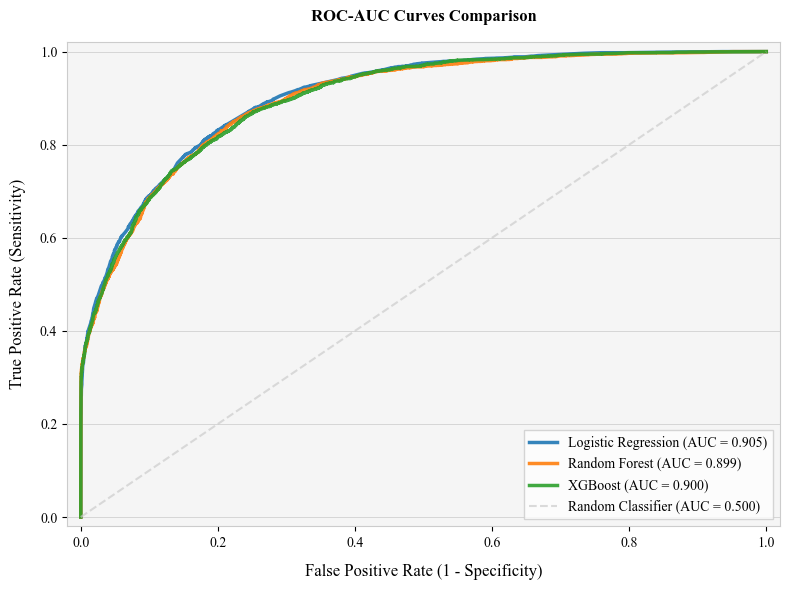

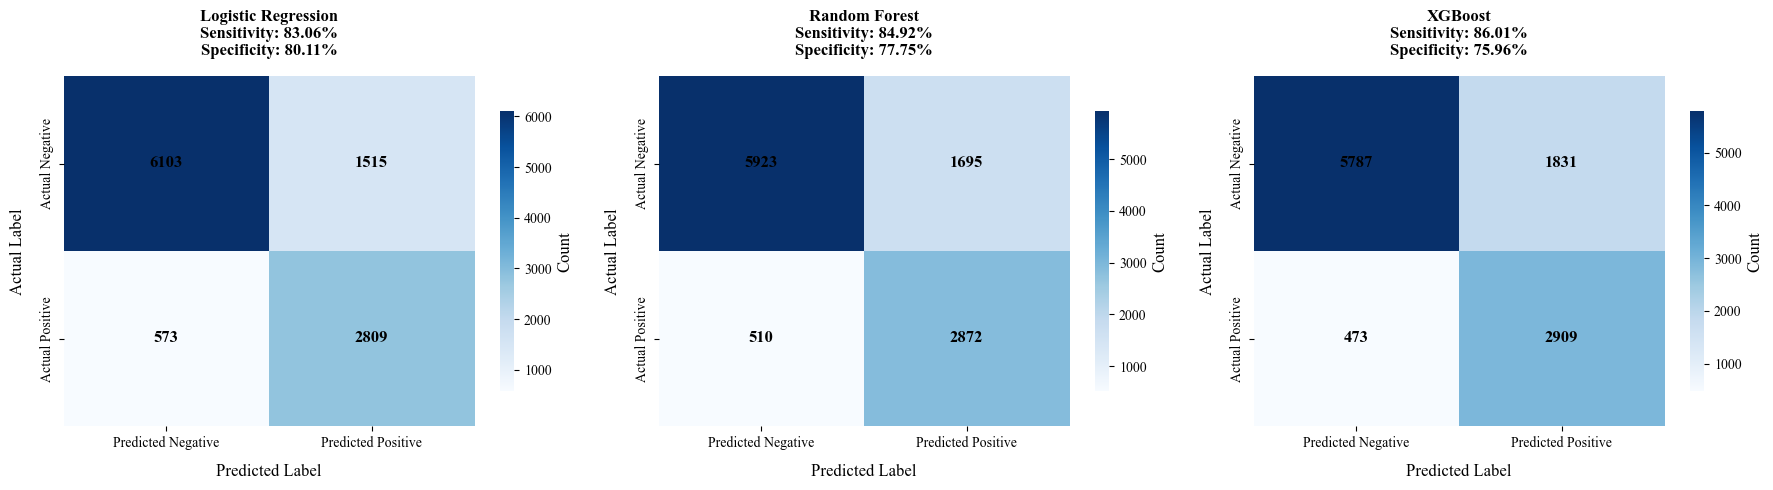

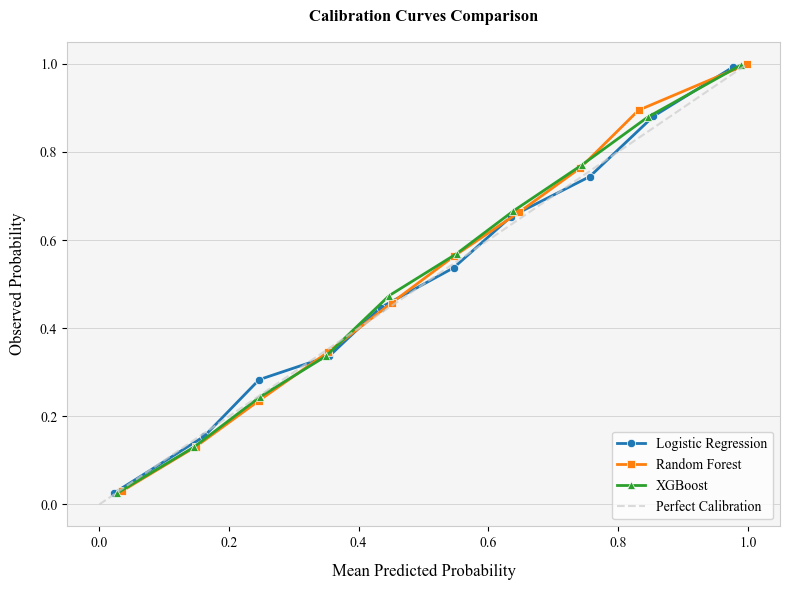


Generating SHAP Waterfall Plots for First 3 Patients...
NOTE: Using calibrated XGBoost model probabilities for display, SHAP values from uncalibrated model


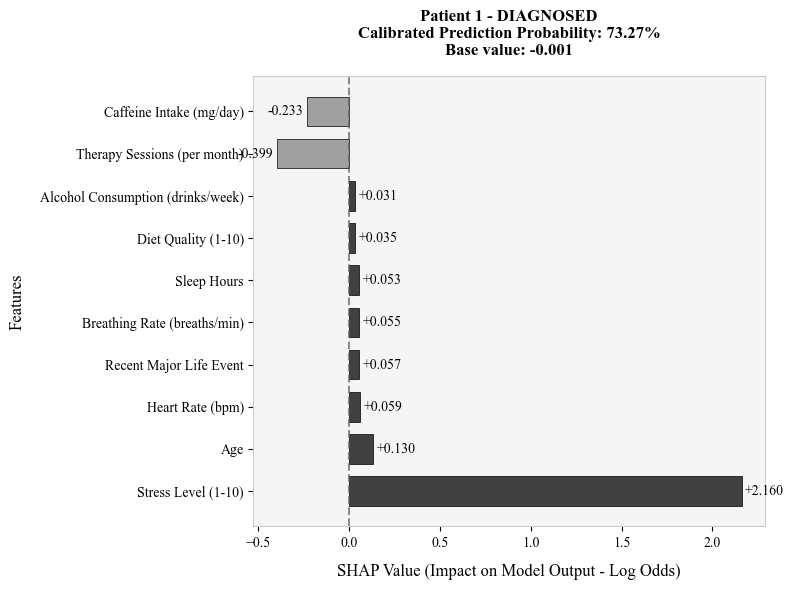

--------------------------------------------------------------------------------


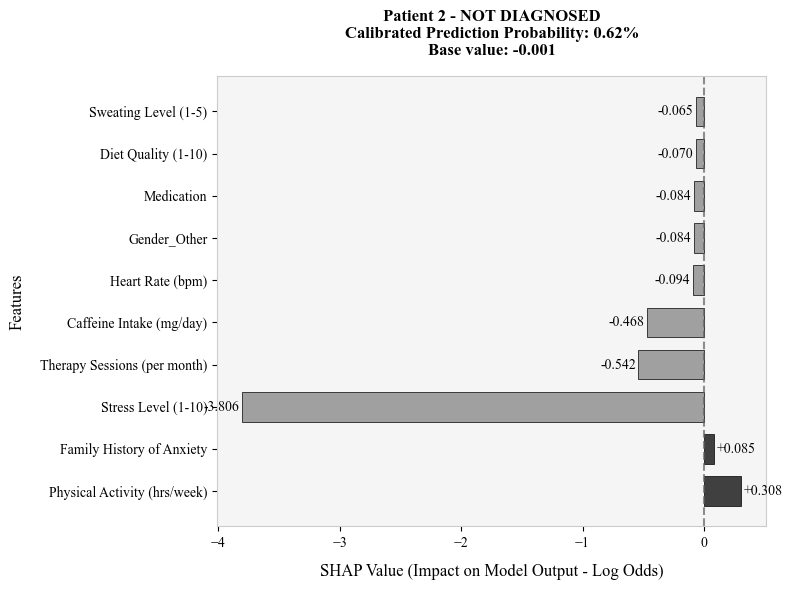

--------------------------------------------------------------------------------


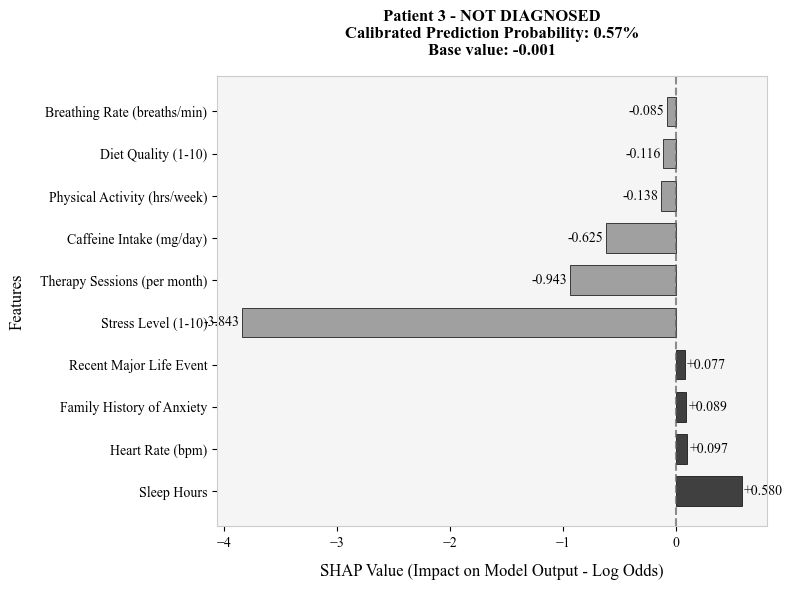

--------------------------------------------------------------------------------
RESULTS TABLE
FIRST 10 PATIENTS
Patient: 1     | Diagnosis: Diagnosed     | Prob: 73.27 % | Risk: High Risk   
  ↑ Increasing: Stress Level (1-10) (+2.160), Age (+0.130), Heart Rate (bpm) (+0.059), Recent Major Life Event (+0.057), Breathing Rate (breaths/min) (+0.055)
  ↓ Decreasing: Therapy Sessions (per month) (-0.399), Caffeine Intake (mg/day) (-0.233), Gender_Other (-0.022), Dizziness (-0.014), Smoking (-0.007)
--------------------------------------------------------------------------------------------------------------
Patient: 2     | Diagnosis: Not Diagnosed | Prob: 0.62  % | Risk: Low Risk    
  ↑ Increasing: Physical Activity (hrs/week) (+0.308), Family History of Anxiety (+0.085), Sleep Hours (+0.047), Occupation_Nurse (+0.039), Occupation_Student (+0.018)
  ↓ Decreasing: Stress Level (1-10) (-3.806), Therapy Sessions (per month) (-0.542), Caffeine Intake (mg/day) (-0.468), Heart Rate (bpm) (-0.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

# Set global font settings - consistent across all plots
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['figure.dpi'] = 100

# Define consistent styling function for all plots with grayscale (matching code A)
def style_plot(ax, title, xlabel, ylabel, legend=True, grid=True):
    """Apply consistent styling to plots with grayscale theme - matching code A"""
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel(xlabel, fontsize=12, labelpad=10, color='black')
    ax.set_ylabel(ylabel, fontsize=12, labelpad=10, color='black')
    if grid:
        # Only show horizontal grid lines
        ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#666666')
        # Disable vertical grid lines
        ax.grid(False, axis='x')
    if legend:
        ax.legend(fontsize=10, frameon=True, loc='upper left', bbox_to_anchor=(1, 1))
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    ax.spines['top'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['left'].set_color('#cccccc')
    ax.spines['right'].set_color('#cccccc')
    return ax

# Define styling function for colored calibration curves
def style_plot_colored(ax, title, xlabel, ylabel, legend=True, grid=True):
    """Apply consistent styling to plots with colored elements"""
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel(xlabel, fontsize=12, labelpad=10, color='black')
    ax.set_ylabel(ylabel, fontsize=12, labelpad=10, color='black')
    if grid:
        # Only show horizontal grid lines
        ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#666666')
        # Disable vertical grid lines
        ax.grid(False, axis='x')
    if legend:
        ax.legend(fontsize=10, frameon=True, loc='lower right')
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    ax.spines['top'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['left'].set_color('#cccccc')
    ax.spines['right'].set_color('#cccccc')
    return ax

# Load and prepare training data
train_data = pd.read_csv("training_dataset.csv")
X_train = train_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_train = train_data["Diagnosed"]
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Load and prepare test data
test_data = pd.read_csv("testing_dataset.csv")
X_test = test_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_test = test_data["Diagnosed"]

# Identifying feature types
numeric_features = X_train.select_dtypes(include=[float, int]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])

# Model pipelines
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", l1_ratio=0.5, C=1.0))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42))
])

# Calibrated models
logreg_model = CalibratedClassifierCV(logreg_pipeline, method="isotonic", cv=5)
rf_model = CalibratedClassifierCV(rf_pipeline, method="isotonic", cv=5)
xgb_model = CalibratedClassifierCV(xgb_pipeline, method="isotonic", cv=5)

# Model training
logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Get predicted probabilities (calibrated)
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Show first 20 predictions
print("\nPredicted percentages (first 20 patients):")
df_probs = pd.DataFrame({
    "Patient": range(1, 21),
    "Diagnosis(1-Anxiety, 0-No Anxiety)": y_test.iloc[:20].values,
    "Logistic Regression (%)": np.round(logreg_prob[:20]*100, 2),
    "Random Forest (%)": np.round(rf_prob[:20]*100, 2),
    "XGBoost (%)": np.round(xgb_prob[:20]*100, 2)
})
print(df_probs.to_string(index=False))

# Find optimal thresholds
def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

logreg_threshold = find_best_threshold(y_test, logreg_prob)
rf_threshold = find_best_threshold(y_test, rf_prob)
xgb_threshold = find_best_threshold(y_test, xgb_prob)

# Plot probability distributions with consistent styling (matching code A)
def plot_probabilities_horizontal(y_true, y_prob, threshold, name):
    df = pd.DataFrame({"Probability": y_prob, "Diagnosis": y_true})
    fig, ax = plt.subplots(figsize=(10, 6))
    # Use grayscale colors - matching code A
    colors = ['#a0a0a0', '#404040']  # Light gray for no anxiety, dark gray for anxiety
    for i, diagnosis in enumerate([0, 1]):
        data = df[df["Diagnosis"] == diagnosis]
        label = "Non-Diagnosed" if diagnosis == 0 else "Diagnosed"
        alpha = 0.6 if diagnosis == 0 else 0.8
        ax.hist(data["Probability"], bins=20, alpha=alpha, color=colors[i], 
                label=label, edgecolor='black', linewidth=0.5)
    ax.axvline(threshold, color='#606060', linestyle="--", linewidth=2, 
               label=f"Optimal Threshold = {threshold:.2f}")
    ax = style_plot(ax, f"{name} - Predicted Probability Distribution", 
                   "Predicted Probability", "Count", grid=False)
    plt.tight_layout()
    plt.show()

plot_probabilities_horizontal(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
plot_probabilities_horizontal(y_test, rf_prob, rf_threshold, "Random Forest")
plot_probabilities_horizontal(y_test, xgb_prob, xgb_threshold, "XGBoost")

# feature importance function with consistent styling (matching code A)
def plot_feature_importance(pipeline_model, name):
    
    classifier = pipeline_model.named_steps["classifier"]

    preprocessor_temp = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ])
    preprocessor_temp.fit(X_train)

    numeric_feature_names = numeric_features
    cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
    feature_names = list(numeric_feature_names) + list(cat_feature_names)

    fig, ax = plt.subplots(figsize=(8, 6))

    if hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        indices = np.argsort(importances)[-15:]
        # Use grayscale bars - matching code A
        bars = ax.barh(range(len(indices)), importances[indices], color='#404040', 
                       edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
        ax = style_plot(ax, f"{name} - Feature Importance (Top 15)", 
                       "Feature Importance", "Features", legend=False, grid=False)
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            print(f"  {feature_names[idx]}: {importances[idx]:.4f}")

    elif hasattr(classifier, "coef_"):
        coefficients = classifier.coef_[0]
        abs_coef = np.abs(coefficients)
        indices = np.argsort(abs_coef)[-15:]
        # Use grayscale: dark gray for positive, light gray for negative - matching code A
        colors = ['#404040' if c > 0 else '#a0a0a0' for c in coefficients[indices]]
        ax.barh(range(len(indices)), coefficients[indices], color=colors, 
                edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='#404040', edgecolor='black', label='Positive (increases risk)'),
                          Patch(facecolor='#a0a0a0', edgecolor='black', label='Negative (decreases risk)')]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=10, 
                 frameon=True)
        ax = style_plot(ax, f"{name} - Feature Coefficients (Top 15)", 
                       "Coefficient Value", "Features", legend=True, grid=False)
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            direction = "increases risk" if coefficients[idx] > 0 else "decreases risk"
            print(f"  {feature_names[idx]}: {coefficients[idx]:.4f} ({direction})")

    ax.axvline(x=0, color='#cccccc', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()


logreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# Plot feature importance for all models
plot_feature_importance(logreg_pipeline, "Logistic Regression")
plot_feature_importance(rf_pipeline, "Random Forest")
plot_feature_importance(xgb_pipeline, "XGBoost")

# evaluation model
def evaluate_model(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

   
    print(f"{name} METRICS (threshold={threshold:.3f})")
    print(f"Confusion Matrix:")
    print(f"  True Negatives: {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives: {tp}")
    print(f"\nKey Performance Metrics:")
    print(f"  • SENSITIVITY (Recall/True Positive Rate): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"  • SPECIFICITY (True Negative Rate): {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  • F1-SCORE: {f1:.4f}")
    print(f"\nAdditional Metrics:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f} ({prec*100:.2f}%)")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Brier Score: {brier:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    return confusion_matrix(y_true, y_pred), {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1_score': f1,
        'precision': prec,
        'accuracy': acc,
        'roc_auc': roc_auc
    }

# Evaluate models
logreg_cm, logreg_metrics = evaluate_model(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
rf_cm, rf_metrics = evaluate_model(y_test, rf_prob, rf_threshold, "Random Forest")
xgb_cm, xgb_metrics = evaluate_model(y_test, xgb_prob, xgb_threshold, "XGBoost")

# Model comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Threshold': [logreg_threshold, rf_threshold, xgb_threshold],
    'Sensitivity (%)': [logreg_metrics['sensitivity']*100, rf_metrics['sensitivity']*100, xgb_metrics['sensitivity']*100],
    'Specificity (%)': [logreg_metrics['specificity']*100, rf_metrics['specificity']*100, xgb_metrics['specificity']*100],
    'F1-Score': [logreg_metrics['f1_score'], rf_metrics['f1_score'], xgb_metrics['f1_score']],
    'Precision (%)': [logreg_metrics['precision']*100, rf_metrics['precision']*100, xgb_metrics['precision']*100],
    'Accuracy (%)': [logreg_metrics['accuracy']*100, rf_metrics['accuracy']*100, xgb_metrics['accuracy']*100],
    'ROC-AUC': [logreg_metrics['roc_auc'], rf_metrics['roc_auc'], xgb_metrics['roc_auc']]
}).round(2)

print("\nMODEL COMPARISON SUMMARY\n", comparison_df.to_string(index=False))

# colored combined graph
fig, ax = plt.subplots(figsize=(8, 6))

# Define distinct colors for each model (not grayscale)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
models = [
    ("Logistic Regression", logreg_prob, colors[0]),
    ("Random Forest", rf_prob, colors[1]),
    ("XGBoost", xgb_prob, colors[2])
]

# Plot ROC curves for all models
for model_name, prob, color in models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, linestyle='-', 
            label=f"{model_name} (AUC = {auc:.3f})", alpha=0.9)

# Plot diagonal reference line
ax.plot([0, 1], [0, 1], color='#cccccc', linestyle='--', linewidth=1.5, alpha=0.7, 
        label='Random Classifier (AUC = 0.500)')

# Style the plot using your existing style_plot function
ax = style_plot(ax, "ROC-AUC Curves Comparison", 
               "False Positive Rate (1 - Specificity)", 
               "True Positive Rate (Sensitivity)", 
               legend=True, grid=True)

# Adjust legend location for this combined plot
ax.legend(fontsize=10, frameon=True, loc='lower right', 
          fancybox=False, edgecolor='#cccccc')

# Set axis limits for better appearance
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Add minor grid lines for better readability
ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()
# Confusion matrices with COLORED heatmap (using 'Blues' colormap for better visualization)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sensitivity_labels = [
    f"Sensitivity: {logreg_metrics['sensitivity']:.2%}\nSpecificity: {logreg_metrics['specificity']:.2%}",
    f"Sensitivity: {rf_metrics['sensitivity']:.2%}\nSpecificity: {rf_metrics['specificity']:.2%}",
    f"Sensitivity: {xgb_metrics['sensitivity']:.2%}\nSpecificity: {xgb_metrics['specificity']:.2%}"
]

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
for idx, (cm, ax, label, name) in enumerate(zip([logreg_cm, rf_cm, xgb_cm], axes, sensitivity_labels, model_names)):
    # Use colored colormap for confusion matrices (Blues)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'],
                annot_kws={'size': 12, 'color': 'black', 'fontweight': 'bold'}, 
                cbar_kws={'label': 'Count', 'shrink': 0.8})
    ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10, color='black')
    ax.set_ylabel("Actual Label", fontsize=12, labelpad=10, color='black')
    ax.set_title(f"{name}\n{label}", fontsize=12, fontweight='bold', pad=15, color='black')
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    # Style the plot background
    ax.set_facecolor('#f5f5f5')
    for spine in ax.spines.values():
        spine.set_color('#cccccc')
plt.tight_layout()
plt.show()

# Calibration curve with grid 
fig, ax = plt.subplots(figsize=(8, 6))
# Use distinct colors for each model 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
markers = ['o', 's', '^']
line_styles = ['-', '-', '-']
for prob, label, color, marker, linestyle in zip([logreg_prob, rf_prob, xgb_prob], 
                                                   ["Logistic Regression", "Random Forest", "XGBoost"],
                                                   colors, markers, line_styles):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(prob_pred, prob_true, marker=marker, markersize=6, linewidth=2, 
            linestyle=linestyle, color=color, label=label, 
            markeredgecolor='white', markeredgewidth=0.5)
ax.plot([0,1], [0,1], linestyle='--', color='#cccccc', linewidth=1.5, alpha=0.7, 
        label='Perfect Calibration')
# Use colored styling function for calibration curves
ax = style_plot_colored(ax, "Calibration Curves Comparison", 
                       "Mean Predicted Probability", 
                       "Observed Probability", grid=True)
plt.tight_layout()
plt.show()

# Get feature names after preprocessing
preprocessor_temp = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])
preprocessor_temp.fit(X_train)

numeric_feature_names = numeric_features
cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = list(numeric_feature_names) + list(cat_feature_names)

# Transform the data
X_train_transformed = preprocessor_temp.transform(X_train)
X_test_transformed = preprocessor_temp.transform(X_test)

# Get the underlying XGBoost model (not the calibrated one)
xgb_model_uncalibrated = xgb_pipeline.named_steps['classifier']

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model_uncalibrated)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_transformed)

# For SHAP waterfall plots, we need to use the uncalibrated model's log odds
# But we'll show the calibrated probability in the title for consistency
# Get the calibrated probabilities for display
xgb_calibrated_prob = xgb_prob  # This is already calibrated

# Improved waterfall plot function with proper formatting (matching code A styling)
# Now using calibrated model probability for display
def plot_grayscale_waterfall(shap_values, expected_value,features,feature_names, calibrated_prob, true_diagnosis, max_display=10, patient_num=None):
    
    # Sort features by absolute SHAP value
    feature_impacts = list(zip(feature_names, shap_values))
    feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Take top features
    top_features = feature_impacts[:max_display]
    
    # Separate positive and negative impacts for sorting within the display
    positive_features = [(name, val) for name, val in top_features if val > 0]
    negative_features = [(name, val) for name, val in top_features if val < 0]
    
    # Sort positive descending, negative ascending (most negative last)
    positive_features.sort(key=lambda x: x[1], reverse=True)
    negative_features.sort(key=lambda x: x[1])
    
    # Combine: positive first (top), then negative (bottom)
    sorted_features = positive_features + negative_features
    
    # Create figure (removed extra space on right since legend is removed)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create bars
    y_positions = range(len(sorted_features))
    bar_colors = []
    bar_values = []
    feature_labels = []
    
    for i, (name, impact) in enumerate(sorted_features):
        feature_labels.append(name)
        bar_values.append(impact)
        if impact > 0:
            bar_colors.append('#404040') 
        else:
            bar_colors.append('#a0a0a0') 
    
    # Create horizontal bars
    bars = ax.barh(y_positions, bar_values, color=bar_colors, 
                   edgecolor='black', linewidth=0.5, height=0.7)
    
    # Add value labels at the end of each bar
    for i, (impact, bar) in enumerate(zip(bar_values, bars)):
        if impact > 0:
            ax.text(impact + 0.02, i, f'+{impact:.3f}', 
                   va='center', fontsize=10, color='black')
        else:
            ax.text(impact - 0.02, i, f'{impact:.3f}', 
                   va='center', ha='right', fontsize=10, color='black')
    
    # Set y-ticks
    ax.set_yticks(y_positions)
    ax.set_yticklabels(feature_labels, fontsize=13)
    
    # Add baseline vertical line
    ax.axvline(x=expected_value, color='#606060', linestyle='--', 
               linewidth=1.5, alpha=0.7)
    
    # Calculate cumulative and final prediction (log odds)
    final_prediction = expected_value + sum(bar_values)
    # Calculate probability from log odds (this matches SHAP's calculation)
    calculated_probability = 1 / (1 + np.exp(-final_prediction))
    
    # Add title with diagnosis and calibrated probability
    diagnosis_text = 'DIAGNOSED' if true_diagnosis == 1 else 'NOT DIAGNOSED'
    title = f"Patient {patient_num} - {diagnosis_text}\nCalibrated Prediction Probability: {calibrated_prob:.2%}\nBase value: {expected_value:.3f}"
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel('SHAP Value (Impact on Model Output - Log Odds)', fontsize=12, labelpad=10, color='black')
    ax.set_ylabel('Features', fontsize=12, labelpad=10, color='black')
    
    # Style the plot (no grid)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    
    # Style spines
    for spine in ax.spines.values():
        spine.set_color('#cccccc')

    plt.tight_layout()
    plt.show()

print("\nGenerating SHAP Waterfall Plots for First 3 Patients...")
print("NOTE: Using calibrated XGBoost model probabilities for display, SHAP values from uncalibrated model")

for i in range(min(3, len(X_test))):
    true_diagnosis = y_test.iloc[i]
    calibrated_prob = xgb_calibrated_prob[i]  # Use calibrated probability for display
    
    plot_grayscale_waterfall(
        shap_values[i],
        explainer.expected_value,
        X_test_transformed[i],
        feature_names,
        calibrated_prob,
        true_diagnosis,
        max_display=10,
        patient_num=i+1
    )
    print("-" * 80)

print("RESULTS TABLE")

# Function to get top features for a patient based on SHAP values
def get_top_shap_features(shap_values_row, feature_names, n_top=5, positive=True):
    """
    Get top n features with highest positive or negative SHAP values
    """
    if positive:
        # Get indices of top positive SHAP values
        indices = np.argsort(shap_values_row)[-n_top:][::-1]
    else:
        # Get indices of top negative SHAP values (most negative)
        indices = np.argsort(shap_values_row)[:n_top]
    
    features = []
    for idx in indices:
        if positive and shap_values_row[idx] > 0:
            features.append(f"{feature_names[idx]} (+{shap_values_row[idx]:.3f})")
        elif not positive and shap_values_row[idx] < 0:
            features.append(f"{feature_names[idx]} ({shap_values_row[idx]:.3f})")
    
    # Pad with empty strings if less than n_top
    while len(features) < n_top:
        features.append("")
    
    return features

# Create risk categories based on predicted probability (using calibrated probabilities for final risk assessment)
def categorize_risk(prob, low_thresh=0.3, high_thresh=0.7):
    if prob < low_thresh:
        return "Low Risk"
    elif prob < high_thresh:
        return "Moderate Risk"
    else:
        return "High Risk"

xgb_risk_category = [categorize_risk(p) for p in xgb_prob]  # Use calibrated probabilities for risk categories

# Get top features for each patient (using SHAP values)
top_increase_features = []
top_decrease_features = []

for i in range(len(xgb_prob)):
    increase_features = get_top_shap_features(shap_values[i], feature_names, n_top=5, positive=True)
    decrease_features = get_top_shap_features(shap_values[i], feature_names, n_top=5, positive=False)
    
    top_increase_features.append(increase_features)
    top_decrease_features.append(decrease_features)

# Create enhanced results table
results_table = pd.DataFrame({
    "Patient": range(1, len(xgb_prob) + 1),
    "Diagnosis(1-Anxiety, 0-No Anxiety)": ["Diagnosed" if val == 1 else "Not Diagnosed" for val in y_test.values],
    "Predicted Prob (%)": np.round(xgb_prob * 100, 2),
    "Risk Category": xgb_risk_category,
    "Top 5 Increasing Risk Factors": [", ".join([f for f in feat if f != ""]) for feat in top_increase_features],
    "Top 5 Decreasing Risk Factors": [", ".join([f for f in feat if f != ""]) for feat in top_decrease_features]
})

# Set pandas display options for left alignment
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 120)
pd.set_option('display.colheader_justify', 'left')

# Display FIRST 10 patients
print("FIRST 10 PATIENTS")
for i in range(min(10, len(results_table))):
    row = results_table.iloc[i]
    print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis(1-Anxiety, 0-No Anxiety)']:<13} | "
          f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
    print(f"  ↑ Increasing: {row['Top 5 Increasing Risk Factors']}")
    print(f"  ↓ Decreasing: {row['Top 5 Decreasing Risk Factors']}")
    print("-" * 110)

# Display LAST 10 patients
print("LAST 10 PATIENTS")
start_idx = max(0, len(results_table) - 10)
for i in range(start_idx, len(results_table)):
    row = results_table.iloc[i]
    print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis(1-Anxiety, 0-No Anxiety)']:<13} | "
          f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
    print(f"  ↑ Increasing: {row['Top 5 Increasing Risk Factors']}")
    print(f"  ↓ Decreasing: {row['Top 5 Decreasing Risk Factors']}")
    print("-" * 110)

# Save full results table to CSV
results_table.to_csv("predictions_with_explanation.csv", index=False)
print("\nFull results table saved to 'predictions_with_explanation.csv'")

# Create summary statistics for risk categories
print("RISK CATEGORY DISTRIBUTION")
risk_summary = results_table.groupby('Risk Category').agg({
    'Patient': 'count',
}).rename(columns={'Patient': 'Count'})
risk_summary['Percentage'] = (risk_summary['Count'] / len(results_table) * 100).round(2)
print(risk_summary.to_string())

# Save model
joblib.dump(xgb_model, 'predictive_model.pkl', compress=3)
print("\nModel saved as predictive_model.pkl")